#### Find the n-th node of inorder traversal 

Given a binary tree, the task is to fuind the n-th node of inorder traversal 

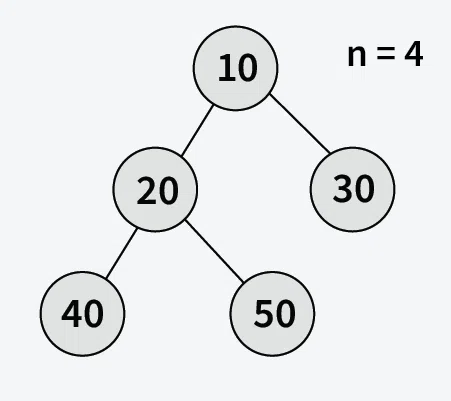


Input: n = 4 
Output: 10 
Inorder travesal: 40 20 50 10 30 
To find the value of the 4th node after inorder traversal 


One approach is to completely traverse the BT generate an output array or list and then return the nth node.

This means that - the algo will fully traverse the tree once and then again look for the element- really a waste of effort 

Another apporach is to simply traverse the tree until the nth element is reached. 

Constraints & boundary conditions: 
- The input tree has to have minimum n elements
- the BT can have only numeric elements 
- 



#### [Naive Approach] - Using inorder traversal 



In [1]:
class Node: 
    def __init__(self, x):
        self.data = x
        self.left = None 
        self.right = None 

def nthInOrder(root, n):
    if root is None:
        return -1 
    
    left = nthInOrder(root.left, n)
    # if nth node is found in left subtree 
    if left != -1 :
        return left 

    if n[0] == 1:
        return root.data

    n[0] -= 1
    right = nthInOrder(root.right, n)
    return right

if __name__ == "__main__":

    # hard coded binary tree.
    #       10
    #     /   \
    #   20     30
    #  /   \
    # 40     50
    root = Node(10)
    root.left = Node(20)
    root.right = Node(30)
    root.left.left = Node(40)
    root.left.right = Node(50)

    n = [4]

    print(nthInOrder(root, n))  


10


## [Expected Approach] - Using morris traversal algorithm



In [4]:
class Node: 
    def __init__(self, x):
        self.data = x 
        self.left = None 
        self.right = None

def nthInOrder(root, n):
    curr = root 
    while curr:
        if curr.left is None:
            if n == 1:
                return curr.data 
            n -= 1 
            curr = curr.right
        else:
            # find inorder predecessor
            pre = curr.left 
            while pre.right is not None and pre.right != curr:
                pre = pre.right 
            if pre.right is None:
                pre.right = curr 
                curr = curr.left 
            else:
                pre.right = None 
                if n == 1:
                    return curr.data
                n -= 1 
                curr = curr.right 

    # if number of nodes is less than n 
    return -1 


if __name__ == "__main__":

    # hard coded binary tree.
    #       10
    #     /   \
    #   20     30
    #  /   \
    # 40     50
    root = Node(10)
    root.left = Node(20)
    root.right = Node(30)
    root.left.left = Node(40)
    root.left.right = Node(50)

    n = 4

    print(nthInOrder(root, n))

10


In [ ]:
# Optimal Solution - Doesn't WORK !!!!

class Node: 
    def __init__(self, x):
        self.data = x 
        self.left = None 
        self.right = None 
        self.leftsize = 0  # number of nodes in the left subtree

def findnth(root, n):
    if not root:
        return None 
    
    if n == root.leftsize +1:
        return root 
    elif n <= root.leftsize:
        return findnth(root.left, n)
    else:
        return findnth(root.right, n - root.leftsize - 1)



if __name__ == "__main__":

    # hard coded binary tree.
    #       10
    #     /   \
    #   20     30
    #  /   \
    # 40     50
    root = Node(10)
    root.left = Node(20)
    root.right = Node(30)
    root.left.left = Node(40)
    root.left.right = Node(50)
    n = 4
    print(findnth(root, n))



    
